In [2]:
import pandas as pd
import numpy as np
import glob
import os
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
#import switch
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
#seed_dirs="../long_sw_100000_fin/"
seed_dirs="../long_sw_100000_fin/"
sw = pd.read_csv('test_files.csv').values
sw

array([['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_0.csv'],
       ['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_1.csv'],
       ['p_0.1_0.3_0.2_0.0001_0.2800000000000001_seed_2.csv'],
       ...,
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_7.csv'],
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_8.csv'],
       ['p_0.9899999999999995_0.3_0.2_0.0001_0.9500000000000006_seed_9.csv']],
      dtype=object)

In [4]:
sw[::1000].shape

(24, 1)

In [5]:
%%time
chosen_seeds = sw[::10][::2]
show_fig_flag=False

days = np.arange(21,45)
row_n = len(chosen_seeds)//2+math.ceil(len(chosen_seeds)%2)
if show_fig_flag:
    fig, ax = plt.subplots(row_n, 2, figsize=(10, row_n*2.5))
    ax = ax.flatten()
else:
    ax=days
    
results = pd.DataFrame([])

for type_start_day, one_ax in zip(days, ax):
    #type_start_day = 1
    beta_prediction_method='real'
    
    if show_fig_flag:
        ax_in_main = [one_ax]
    else:
        ax_in_main = None

    all_rmse_I, all_rmse_Inc, all_rmse_Beta, \
        all_r2, all_r2_Inc, all_r2_full, all_r2_Inc_full,\
        all_peak, execution_time, start_days,df_on_switch = \
            plot_hyb.main_f('seir', count_stoch_line=0, 
                           beta_prediction_method=beta_prediction_method, 
                           type_start_day=type_start_day, seed_numbers=chosen_seeds,
                           show_fig_flag=show_fig_flag, seed_dirs=seed_dirs, 
                           sigma=0.3, gamma=0.2,
                           ax = ax_in_main, model_path='', perc_switch=0.01,
                           is_filename=True, on_incidence=True,
                           switch_on_incidence=False, detailed=True,
                           topology='sw')
    
    sww = pd.Series(chosen_seeds.flatten()).str.split('_',expand=True)
    sww.columns = ['p','beta','sigma','gamma','initi',
               'alpha','seed','nseed']
    sww[['beta','alpha']] = sww[['beta','alpha']].astype(float).round(2)

    # creating a dataframe for peaks
    all_peak = pd.DataFrame(all_peak, 
                    columns=['actual_peak_I', 'predicted_peak_I', 
                            'actual_peak_Inc', 'predicted_peak_inc',
                            'actual_peak_day', 'predicted_peak_day',
                            'actual_peak_day_Inc', 'predicted_peak_day_inc'])
    # creating a dataframe for peaks RMSE, predicted time, start day
    rmse_df = pd.DataFrame({
        'type_start_day': start_days,
        'rmse_I': all_rmse_I,
        'rmse_Inc': all_rmse_Inc,
        'rmse_Beta': all_rmse_Beta,
        'r2': all_r2,
        'r2_Inc': all_r2_Inc,
        'r2_full': all_r2_full,
        'r2_Inc_full': all_r2_Inc_full,
        'time_predict': execution_time,
    })
    df_on_switch = pd.DataFrame(df_on_switch, 
                                columns = ['S','E','I','R','Beta','incidence'])
    seeds_info = pd.concat([sww[['beta','alpha']], 
                            pd.DataFrame(chosen_seeds, columns=['file']), 
                            df_on_switch], axis=1)
    # merging dataframes
    full_one = pd.concat([seeds_info, rmse_df, all_peak], axis=1)
    results = pd.concat([results, full_one], axis=0)
    
results = results.reset_index(drop=True)
print(results.shape)

filtered = results[results.type_start_day<results.actual_peak_day]
filtered[['S','E','I','R','incidence']
        ] = (filtered[['S','E','I','R','incidence']]/100000).round(4)

filtered['days_until_peak_I'] = filtered.actual_peak_day - filtered.type_start_day
filtered['ab'] = (filtered.beta*filtered.alpha).round(3)

print(filtered.shape)
filtered.head()


(28800, 26)
(19851, 28)
CPU times: total: 7min 34s
Wall time: 7min 38s


,beta,alpha,file,S,E,I,R,Beta,incidence,type_start_day,...,actual_peak_I,predicted_peak_I,actual_peak_Inc,predicted_peak_inc,actual_peak_day,predicted_peak_day,actual_peak_day_Inc,predicted_peak_day_inc,days_until_peak_I,ab
87,0.15,0.99,p_0.14999999999999997_0.3_0.2_0.0001_0.9900000...,0.9896,0.0,0.0001,0.0102,0.000001,0.0,21,...,18,10.0,5.0,2.0,52,49,30,21,31,0.148
98,0.16,0.84,p_0.15999999999999998_0.3_0.2_0.0001_0.8400000...,0.8399,0.0,0.0000,0.1601,-0.000000,0.0,21,...,11,1.0,5.0,0.0,120,21,118,21,99,0.134
100,0.16,0.90,p_0.15999999999999998_0.3_0.2_0.0001_0.9000000...,0.8998,0.0,0.0000,0.1001,0.000000,0.0,21,...,22,16.0,6.0,4.0,132,131,107,131,111,0.144
102,0.16,0.98,p_0.15999999999999998_0.3_0.2_0.0001_0.9800000...,0.9798,0.0,0.0000,0.0202,0.000003,0.0,21,...,12,59.0,4.0,14.0,68,142,44,142,47,0.157
123,0.18,0.81,p_0.17999999999999997_0.3_0.2_0.0001_0.8100000...,0.8097,0.0,0.0000,0.1903,0.000008,0.0,21,...,11,10.0,3.0,3.0,43,40,11,39,22,0.146


In [6]:
filtered.columns

Index(['beta', 'alpha', 'file', 'S', 'E', 'I', 'R', 'Beta', 'incidence',
       'type_start_day', 'rmse_I', 'rmse_Inc', 'rmse_Beta', 'r2', 'r2_Inc',
       'r2_full', 'r2_Inc_full', 'time_predict', 'actual_peak_I',
       'predicted_peak_I', 'actual_peak_Inc', 'predicted_peak_inc',
       'actual_peak_day', 'predicted_peak_day', 'actual_peak_day_Inc',
       'predicted_peak_day_inc', 'days_until_peak_I', 'ab'],
      dtype='object')

In [7]:
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator, MultipleLocator

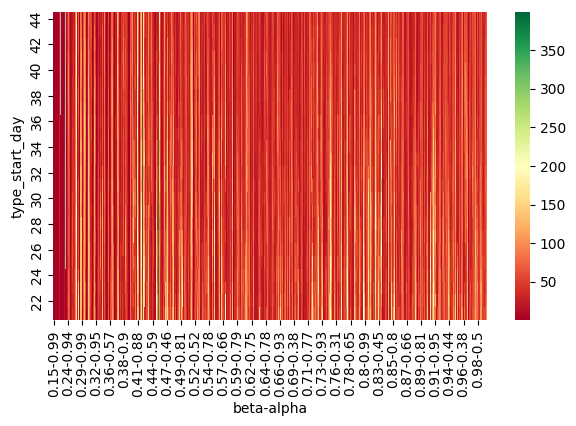

In [8]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot(columns=['beta','alpha'], index='type_start_day', 
                             values='rmse_Inc')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

In [9]:
gg = filtered.groupby(['beta','alpha'])
groupes = gg.groups.keys()
len(list(groupes))

829

<Axes: >

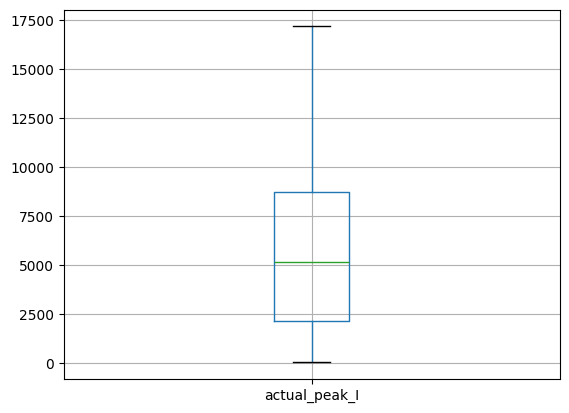

In [10]:
filtered[['actual_peak_I']].boxplot()

In [11]:
gg2 = filtered[filtered.actual_peak_I>=5000].groupby(['beta','alpha'])
groupes2 = gg2.groups.keys()
len(list(groupes2))

419

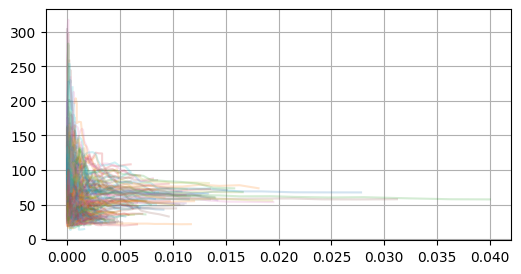

In [12]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.I, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
    
plt.grid()
#plt.ylim(-10,800)

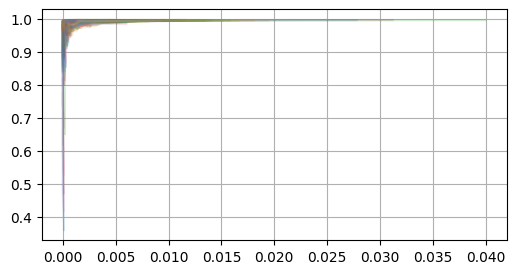

In [13]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.I, one_group.r2_Inc, 
         marker='', ls='-', alpha=.2)
    
plt.grid()

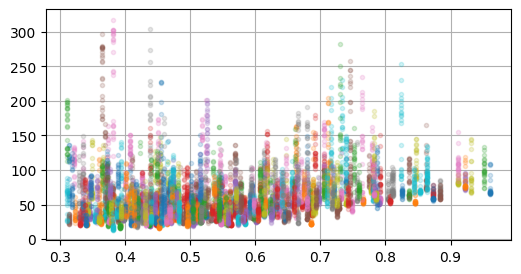

In [14]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.beta*one_group.alpha, one_group.rmse_Inc, 
         marker='.', ls='', alpha=.2)
    
plt.grid()
#plt.ylim(-10,800)

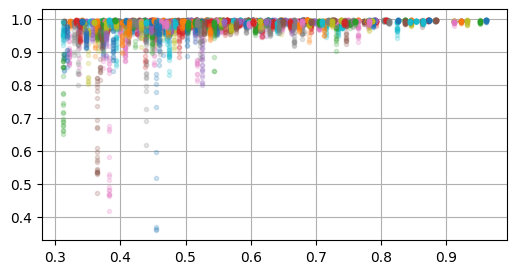

In [15]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.ab, one_group.r2_Inc, 
         marker='.', ls='', alpha=.2)
    
plt.grid()
#plt.ylim(-10,800)

In [16]:
filtered.shape, filtered['ab'].nunique()

((19851, 28), 461)

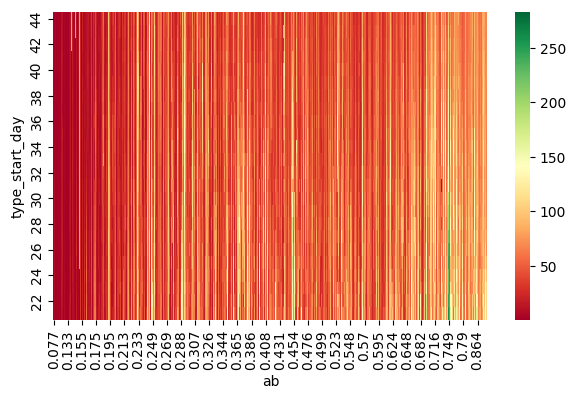

In [17]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot_table(columns='ab', index='type_start_day', 
                             values='rmse_Inc', aggfunc='mean')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

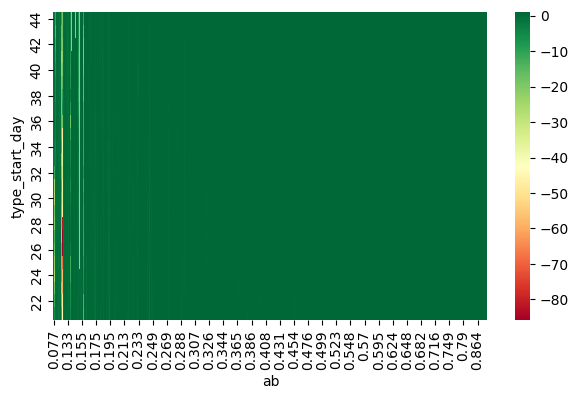

In [18]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot_table(columns='ab', index='type_start_day', 
                             values='r2_Inc', aggfunc='mean')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

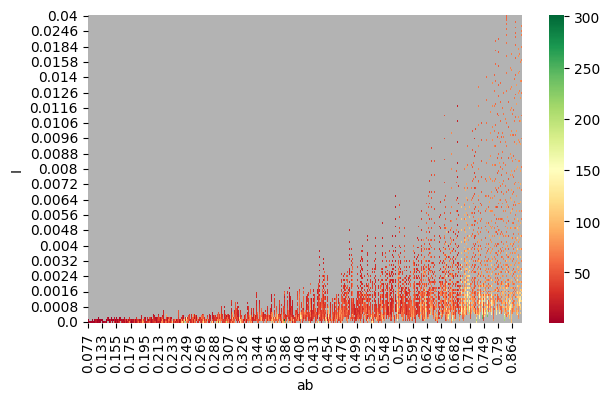

In [19]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot_table(columns='ab', index='I', 
                             values='rmse_Inc', aggfunc='mean')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

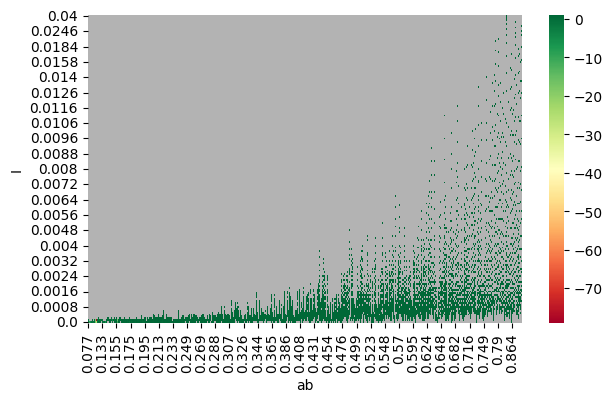

In [20]:
fig, ax = plt.subplots(1,1,figsize=(7,4))

data = filtered.pivot_table(columns='ab', index='I', 
                             values='r2_Inc', aggfunc='mean')
ax_i = ax
cmap = mpl.cm.RdYlGn
sns.heatmap(data.sort_index(level=1, ascending=False), 
            #yticklabels = 4, 
            #xticklabels=10,
            #vmin=0.8, vmax=1,
            #vmax=40, 
            cmap=cmap,
            ax=ax_i, linewidths=0.0, rasterized=True)

ax_i.collections[0].cmap.set_bad('0.7')
#ax_i.set_xlabel(r'$\beta$')
#ax_i.set_ylabel(r'$\alpha$')
cbar = ax_i.collections[0].colorbar
#cbar.set_label('days', rotation=0)

In [21]:
len(list(groupes2)[::200])

3

In [22]:
mpl.cm.tab10.colors

((0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529))

Видимо, тк (2й сид) и за 2-3 недели хорошо прогноизируем, то раз у 1-го сида пик ближе, то тем более хороший результат.

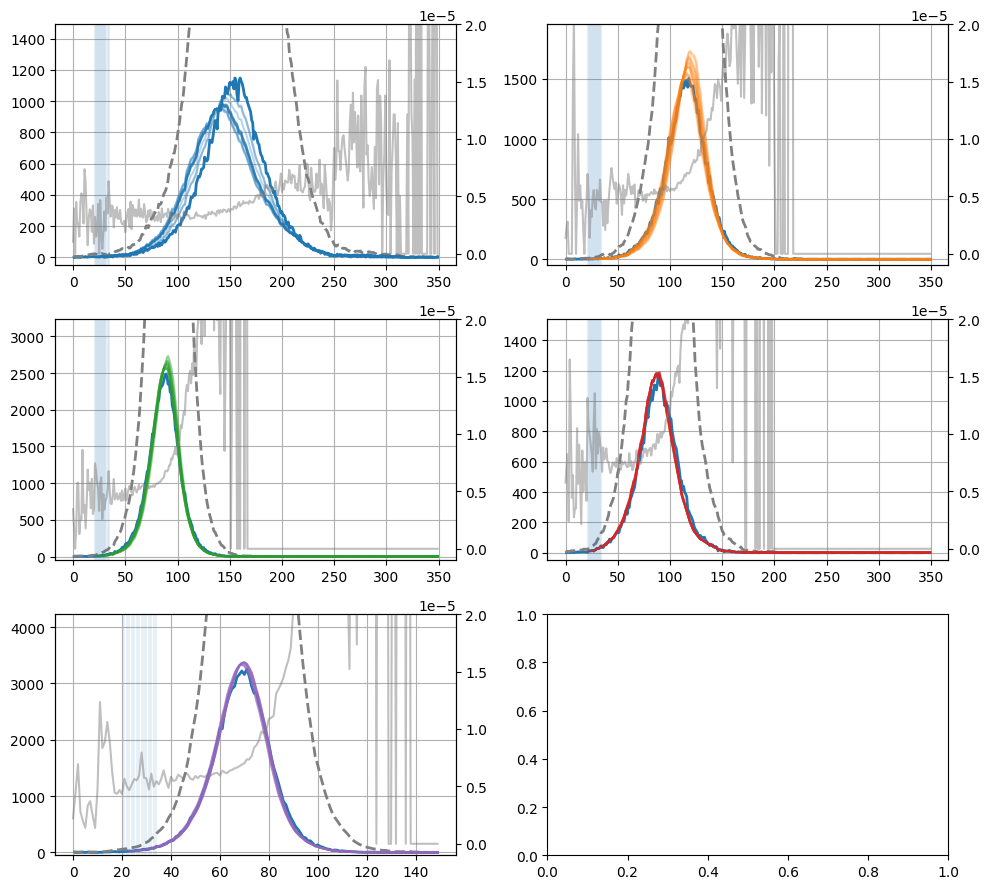

In [23]:
fig, ax = plt.subplots(3, 2, figsize=(10, 9), squeeze=False)
ax = ax.flatten()
sigma, gamma = 0.3,0.2
initi=0.0001
seed='0.csv'
#brown

for ax0, color, group_id in zip(ax, mpl.cm.tab10.colors, 
                                range(len(list(groupes2)[::100]))):
    group_label = list(groupes2)[::100][group_id]
    beta, alpha = group_label

    filen = gg2.get_group(group_label)['file'].values[0]
    filen = f'p_{round(float(beta), 2)}_{sigma}_{gamma}_{initi}_{round(float(alpha), 2)}_seed_{seed}' 
    seed_df = pd.read_csv(seed_dirs+filen)
    seed_df = pd.read_csv(seed_dirs+filen)

    temp = seed_df[['E','S']].shift([0,1])
    # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
    seed_df['incidence'] = (temp['E_1'] - temp['E_0']) - \
                        (temp['S_0'] - temp['S_1'])
    ax0.plot(seed_df.incidence, lw=2)
    ax0.plot(seed_df.I, lw=2, color='gray', ls='--')
    ax_b = ax0.twinx()
    ax_b.plot(seed_df.Beta, color='gray', alpha=.5)
    
    for i in range(21,35):
        start_days=[]
        start_day = i
        start_days.append(start_day)
        predicted_days = np.arange(start_day, seed_df.shape[0])
        # choosing the days for prediction
        predicted_days = np.arange(start_day, seed_df.shape[0])

        beggining_beta, predicted_beta, \
                predicted_I = predict_Beta_I.predict_beta(
                                'seir', seed_df,
                                'real', 
                                predicted_days, False, 
                                0, float(sigma), float(gamma),
                                '', '', 4)
        


        predicted_Inc = np.zeros((0+1, 
                                      predicted_days.shape[0]))
        y = seed_df.iloc[predicted_days[0],:4]
        # predict the Infected compartment trajectory
        ss,ee,predicted_I[0],\
            _ = predict_Beta_I.predict_I('seir', y,
                                          predicted_days-start_day,
                                          predicted_beta,
                                          float(sigma), float(gamma), 'det')
        # Inc_t = (E_t-1 - E_t) - (S_t - S_t-1)
        from_last = seed_df['incidence'].iloc[predicted_days[0]]
        predicted_Inc[0] = np.append(from_last, 
                                   (ee[:-1] - ee[1:]) - \
                                       (ss[1:] - ss[:-1]))
        predicted_Inc[0][predicted_Inc[0]<0] = 0
        
        ax0.plot(predicted_days,predicted_Inc[0], color=color,alpha=.3) 
        ax0.axvline(i, alpha=.1)
        #ax0.set_xlim(-5,70)
        
    ax_b.set_ylim(-1e-6,2e-5)
    ax0.grid()
    ax0.set_ylim(-50, seed_df.incidence.max()*1.3)
    
plt.tight_layout()

136.75554477737137 141
84.332494359311 101
89.5958165002502 72
31.491881522444928 71
78.78249913872138 52


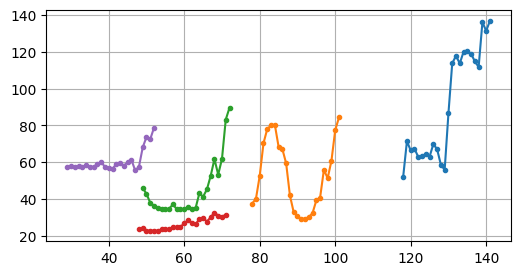

In [24]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::100]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.days_until_peak_I, one_group.rmse_Inc, 
         marker='.', ls='-', alpha=1)
    print(one_group.rmse_Inc.iloc[0], one_group.days_until_peak_I.iloc[0])
plt.grid()


136.75554477737137 141
84.332494359311 101
89.5958165002502 72
31.491881522444928 71
78.78249913872138 52


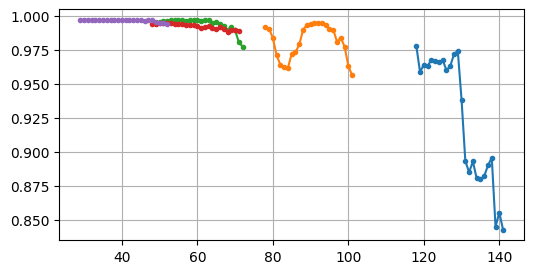

In [25]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::100]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.days_until_peak_I, one_group.r2_Inc, 
         marker='.', ls='-', alpha=1)
    print(one_group.rmse_Inc.iloc[0], one_group.days_until_peak_I.iloc[0])
plt.grid()


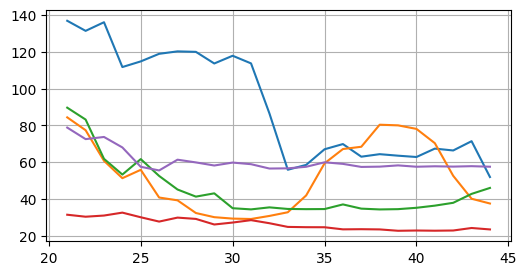

In [26]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::100]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.type_start_day, one_group.rmse_Inc, 
         marker='', ls='-', alpha=1)
    
plt.grid()

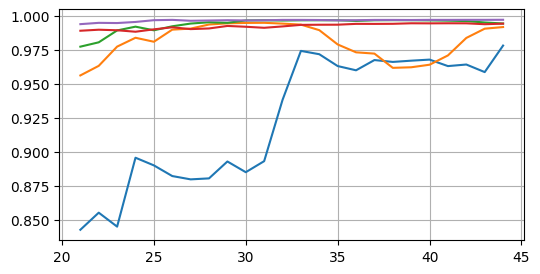

In [27]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::100]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.type_start_day, one_group.r2_Inc, 
         marker='', ls='-', alpha=1)
    
plt.grid()

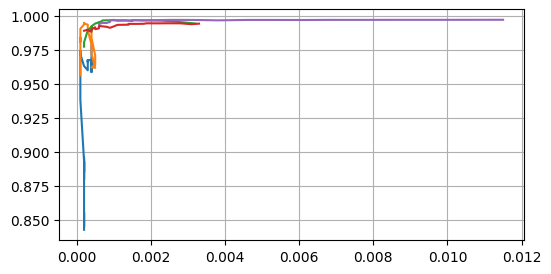

In [39]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::100]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.I, one_group.r2_Inc, 
         marker='', ls='-', alpha=1)
  
plt.grid()

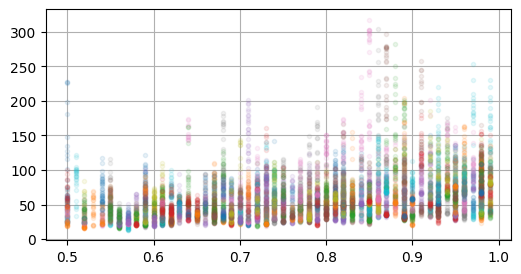

In [30]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::1]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.alpha, one_group.rmse_Inc, 
         marker='.', ls='', alpha=.1)
    
plt.grid()

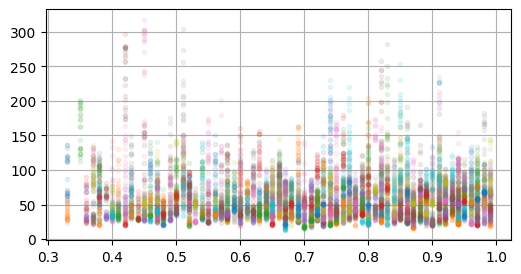

In [31]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::1]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.beta, one_group.rmse_Inc, 
         marker='.', ls='', alpha=.1)
    
plt.grid()


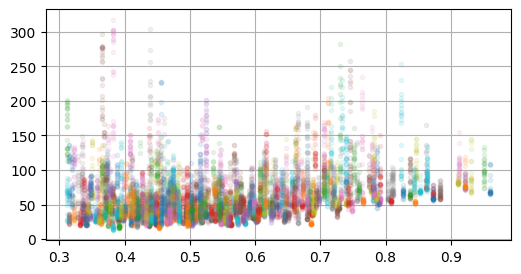

In [32]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::1]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.ab, one_group.rmse_Inc, 
         marker='.', ls='', alpha=.1)
    
plt.grid()

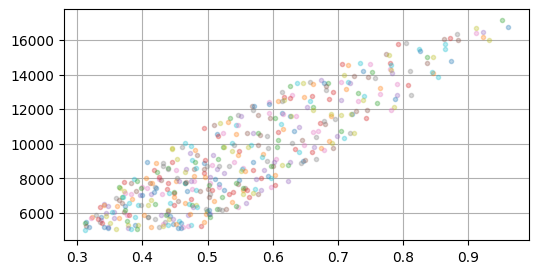

In [33]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::1]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.ab.iloc[0], one_group.actual_peak_I.iloc[0], 
         marker='.', ls='', alpha=.3)
    
plt.grid()

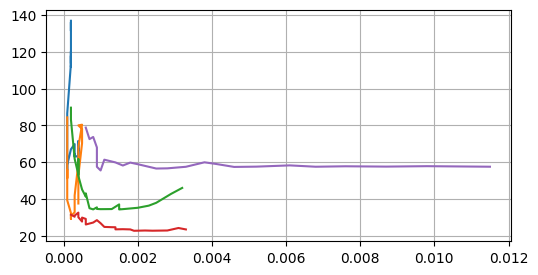

In [34]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::100]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.I, one_group.rmse_Inc, 
         marker='', ls='-', alpha=1)
    
plt.grid()

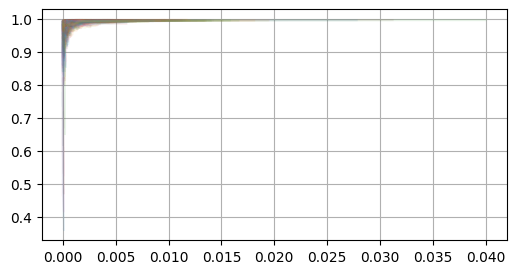

In [35]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2)[::1]:
    one_group = gg2.get_group(group)
    plt.plot(one_group.I, one_group.r2_Inc, 
         marker='', ls='-', alpha=.1)
    
plt.grid()
#plt.ylim(-10,800)

(-10.0, 800.0)

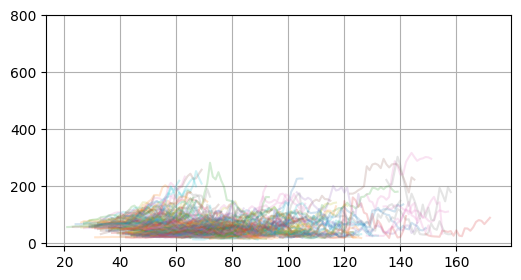

In [36]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.days_until_peak_I, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
    
plt.grid()
plt.ylim(-10,800)

(-10.0, 800.0)

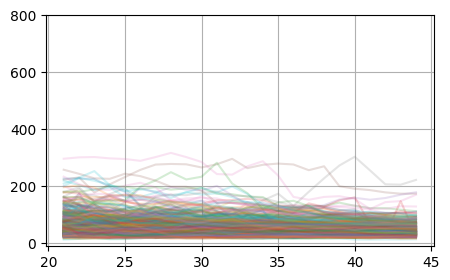

In [37]:
fig, ax = plt.subplots(1,1, figsize=(5,3))
for group in list(groupes2):
    one_group = gg2.get_group(group)
    plt.plot(one_group.type_start_day, one_group.rmse_Inc, 
         marker='', ls='-', alpha=.2)
plt.grid()
plt.ylim(-10,800)